![iSA logo](../iSA_logo.png)
### Materiały do zajęć Statystyka
#### Kurs Junior Data Scientist

**Wojciech Artichowicz**

### Estymacja parametryczna (praktyczne wykorzystanie metody największej wiarygodności)

W praktyce często zachodzi konieczność poznania rozkładu populacji generalnej a nie tylko próby. Szczególnie istotne mogą okazać się oszacowane wartości parametrów rozkładów prawdopodobieństwa. W sytuacji takiej zwykle postępuje się następująco:

 1. Utworzenie histogramu
 2. Wybór rozkładu, z którego może pochodzić próba
 3. Wyprowadzenie estymatorów*
 4. Obliczenie wartości estymatorów
 
*)W statystyce praktycznej rzadko występuje konieczność wyprowadzenia estymatorów. Wzory opisujące estymatory (i ich własności) dla szeroko stosowanych rozkładów (jest ich około 300) są dostępne np. w podręcznikach. W bibliotekach scipy.stats oraz statsmodels istnieją funkcje umożliwiające estymację parametrów na podstawie próby.
 
Rozkłady z biblioteki [scipy](https://docs.scipy.org/doc/scipy/reference/stats.html) posiadają metodę (statyczną) fit(), która umożliwia obliczenie estymatorów przy pomocy metody największej wiarygodności.

In [1]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
%matplotlib inline

**Wygenerowanie próby pochodzącej z rozkładu normalnego**

W praktyce te dane pochodziłyby z pomiarów pewnej wielkości np. wzrostu, temperatury, wysokości przychodu itp. 

In [2]:
m = 125
s = 32
X = st.norm(m,s).rvs(1000)

#### Utworzenie histogramu

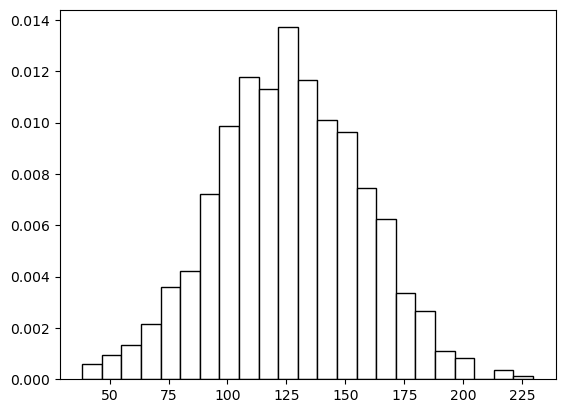

In [3]:
plt.hist(X, density = True,bins = "auto",color = "white", edgecolor = "black")
pass

#### Określenie wartości estymatorów parametrów rozkładu metodą największej wiarygodności

Tu rozkład ma dwa parametry: $\mu$ oraz $\sigma$.

In [4]:
(e_m, e_s) = st.norm.fit(X) # "dopasowanie rozkładu", czyli obliczenie wartości parametrów
(e_m, e_s) # estymowane wartości parametrów

(126.02199722037317, 31.095857918047447)

**Uwaga:** Termin "dopasowanie rozkładu" jest terminem używanym potocznie. Formalnie jest to stwierdzenie niepoprawne. Populacja generalna podlega pewnemu określonemu rozkładowi, którego nie znamy. Na podstawie próby szacowane są parametry modelu statystycznego. Nie następuje natomiast dopasowanie rozkładu do próby.

#### Utworzenie wykresu gęstości rozkładu prawdopodobieństwa populacji generalniej i estymowanej na podstawie próby

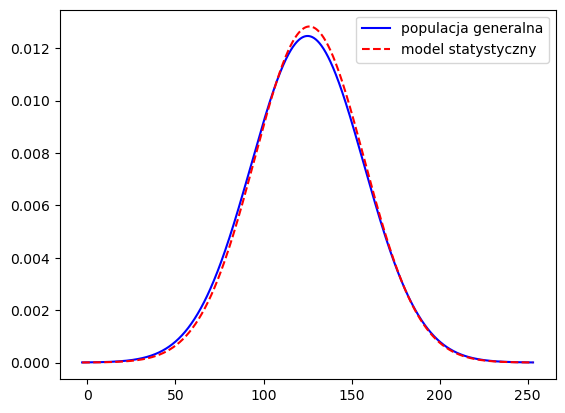

In [5]:
xn = np.linspace(m-4*s,m+4*s,1000) # wektor wartości x

poulacjaGeneralna = st.norm(m,s)
populacjaEstymowana = st.norm(e_m,e_s)

plt.plot(xn,poulacjaGeneralna.pdf(xn),"blue")
plt.plot(xn,populacjaEstymowana.pdf(xn),"red",linestyle = "dashed")

plt.legend(["populacja generalna","model statystyczny"])
pass